In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from preprocessing import TextPreprocessor
from models import SentimentAnalyzer
import os


sns.set_theme(style='whitegrid')

c:\dev\nlp\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 load del dataset

In [2]:
PATH = 'bluesky_time_series_data.csv'

df = pd.read_csv(PATH)
df.head()

,id,cid,created_at,indexed_at,text_raw,text_clean,hashtags,keyword_source,author_did,author_handle,...,author_createdAt,like_count,repost_count,reply_count,quote_count,bookmark_count,viewer_like,viewer_repost,viewer_pinned,viewer_bookmarked
0,at://did:plc:574o3rvmxpg6iq3x5ng2ncgf/app.bsky...,bafyreiehhr3ijy2ey6cqo47vzd4axwnh7dj6nu5mlrd4o...,2026-01-01T22:07:40.882Z,2026-01-01T22:07:41.631Z,Meloni sente Trump e frena sul Donbass: “Decid...,meloni sente trump e frena sul donbass decidon...,[],meloni,did:plc:574o3rvmxpg6iq3x5ng2ncgf,mediasit.skyfleet.blue,...,2023-08-27T20:23:54.944Z,0,0,0,1,0,NaN,NaN,NaN,False
1,at://did:plc:m3yth7migrk4nguhrtaesc7m/app.bsky...,bafyreigeeb5um7gzy6mkph7mddov3pe4phwdqi5fg5fbw...,2026-01-01T21:46:16.847Z,2026-01-01T21:46:17.632Z,Questo è il grafico che certifica che la Melon...,questo è il grafico che certifica che la melon...,[],meloni,did:plc:m3yth7migrk4nguhrtaesc7m,texwiller.bsky.social,...,2023-11-28T06:45:55.936Z,2,0,0,0,0,NaN,NaN,NaN,False
2,at://did:plc:6tngxystbigl4pm6ffr4jhi2/app.bsky...,bafyreiaefdsy3srmd64pwpr7kxuek5sun6w2ramzr6tsm...,2026-01-01T20:29:57.043Z,2026-01-01T20:30:03.734Z,"🚨 Italia \nMeloni ""abbiamo mantenuto tutte le ...",italia meloni abbiamo mantenuto tutte le prome...,[],meloni,did:plc:6tngxystbigl4pm6ffr4jhi2,lacanoggi.eurosky.social,...,2024-02-10T11:17:52.005Z,7,0,0,0,0,NaN,NaN,NaN,False
3,at://did:plc:574o3rvmxpg6iq3x5ng2ncgf/app.bsky...,bafyreibwstadcqczbu5c3cegor4ifncke7aa3hbyjgytl...,2026-01-01T20:06:05.379Z,2026-01-01T20:06:06.149Z,"Meloni elogia il Colle, ma la Repubblica di Gi...",meloni elogia il colle ma la repubblica di gio...,[],meloni,did:plc:574o3rvmxpg6iq3x5ng2ncgf,mediasit.skyfleet.blue,...,2023-08-27T20:23:54.944Z,0,0,0,0,0,NaN,NaN,NaN,False
4,at://did:plc:ngbx3rfvovh2bmgueezurs4w/app.bsky...,bafyreieiwnjtxs7yzw5brgcmtwtp65mqnrhpgqpdamrkm...,2026-01-01T18:00:44+01:00,2026-01-01T17:00:45.034Z,La superbia di Giorgia meloni https://www.gayb...,la superbia di giorgia meloni,[],meloni,did:plc:ngbx3rfvovh2bmgueezurs4w,gayburg.bsky.social,...,2024-11-18T19:04:09.447Z,1,0,0,0,0,NaN,NaN,NaN,False


tolgo maiuscole, numeri, url, menzioni e hashtag

In [3]:
preprocessor = TextPreprocessor()

df['text_clean'] = df['text_raw'].astype(str).apply(preprocessor.clean_text)

df['created_at'] = pd.to_datetime(df['created_at'], format='ISO8601', utc=True)
df['date'] = df['created_at'].dt.date

df.head()

,id,cid,created_at,indexed_at,text_raw,text_clean,hashtags,keyword_source,author_did,author_handle,...,like_count,repost_count,reply_count,quote_count,bookmark_count,viewer_like,viewer_repost,viewer_pinned,viewer_bookmarked,date
0,at://did:plc:574o3rvmxpg6iq3x5ng2ncgf/app.bsky...,bafyreiehhr3ijy2ey6cqo47vzd4axwnh7dj6nu5mlrd4o...,2026-01-01 22:07:40.882000+00:00,2026-01-01T22:07:41.631Z,Meloni sente Trump e frena sul Donbass: “Decid...,meloni sente trump e frena sul donbass decidon...,[],meloni,did:plc:574o3rvmxpg6iq3x5ng2ncgf,mediasit.skyfleet.blue,...,0,0,0,1,0,NaN,NaN,NaN,False,2026-01-01
1,at://did:plc:m3yth7migrk4nguhrtaesc7m/app.bsky...,bafyreigeeb5um7gzy6mkph7mddov3pe4phwdqi5fg5fbw...,2026-01-01 21:46:16.847000+00:00,2026-01-01T21:46:17.632Z,Questo è il grafico che certifica che la Melon...,questo è il grafico che certifica che la melon...,[],meloni,did:plc:m3yth7migrk4nguhrtaesc7m,texwiller.bsky.social,...,2,0,0,0,0,NaN,NaN,NaN,False,2026-01-01
2,at://did:plc:6tngxystbigl4pm6ffr4jhi2/app.bsky...,bafyreiaefdsy3srmd64pwpr7kxuek5sun6w2ramzr6tsm...,2026-01-01 20:29:57.043000+00:00,2026-01-01T20:30:03.734Z,"🚨 Italia \nMeloni ""abbiamo mantenuto tutte le ...",italia meloni abbiamo mantenuto tutte le prome...,[],meloni,did:plc:6tngxystbigl4pm6ffr4jhi2,lacanoggi.eurosky.social,...,7,0,0,0,0,NaN,NaN,NaN,False,2026-01-01
3,at://did:plc:574o3rvmxpg6iq3x5ng2ncgf/app.bsky...,bafyreibwstadcqczbu5c3cegor4ifncke7aa3hbyjgytl...,2026-01-01 20:06:05.379000+00:00,2026-01-01T20:06:06.149Z,"Meloni elogia il Colle, ma la Repubblica di Gi...",meloni elogia il colle ma la repubblica di gio...,[],meloni,did:plc:574o3rvmxpg6iq3x5ng2ncgf,mediasit.skyfleet.blue,...,0,0,0,0,0,NaN,NaN,NaN,False,2026-01-01
4,at://did:plc:ngbx3rfvovh2bmgueezurs4w/app.bsky...,bafyreieiwnjtxs7yzw5brgcmtwtp65mqnrhpgqpdamrkm...,2026-01-01 17:00:44+00:00,2026-01-01T17:00:45.034Z,La superbia di Giorgia meloni https://www.gayb...,la superbia di giorgia meloni,[],meloni,did:plc:ngbx3rfvovh2bmgueezurs4w,gayburg.bsky.social,...,1,0,0,0,0,NaN,NaN,NaN,False,2026-01-01


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def print_report(dataframe, column_name):
    print(f"modello: {column_name}")
    print(dataframe[f'sentiment_{column_name}'].value_counts())

    colors_dict = {
        'negative': '#e74c3c',
        'neutral': '#95a5a6',
        'positive': '#2ecc71'
    }

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.countplot(
        x=f'sentiment_{column_name}', 
        data=dataframe, 
        order=['negative', 'neutral', 'positive'],
        palette=colors_dict,
        ax=axes[0]
    )
    axes[0].set_title(f"Distribuzione Sentiment ({column_name})")

    df_time_ml = dataframe.groupby(['date', f'sentiment_{column_name}']).size().unstack(fill_value=0)
    df_time_ml = df_time_ml.reindex(columns=['negative', 'neutral', 'positive'], fill_value=0)
    
    df_time_ml.plot(
        kind='line', 
        marker='o', 
        color=[colors_dict['negative'], colors_dict['neutral'], colors_dict['positive']], 
        ax=axes[1]
    )
    axes[1].set_title(f"Andamento del Sentiment nel Tempo ({column_name})")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

def save_dataframe_to_csv(dataframe, filename):
    dataframe.to_csv(filename, index=False)
    print(f"DataFrame salvato in {filename}")

In [5]:
analyzer = SentimentAnalyzer()

Inizio analisi su 13465 post, uso il modello: cardiffnlp/twitter-xlm-roberta-base-sentiment...
Progresso: 0% completato (32/13465)
Progresso: 0% completato (64/13465)
Progresso: 0% completato (96/13465)
Progresso: 0% completato (128/13465)
Progresso: 1% completato (160/13465)
Progresso: 1% completato (192/13465)
Progresso: 1% completato (224/13465)
Progresso: 1% completato (256/13465)
Progresso: 2% completato (288/13465)
Progresso: 2% completato (320/13465)
Progresso: 2% completato (352/13465)
Progresso: 2% completato (384/13465)
Progresso: 3% completato (416/13465)
Progresso: 3% completato (448/13465)
Progresso: 3% completato (480/13465)
Progresso: 3% completato (512/13465)
Progresso: 4% completato (544/13465)
Progresso: 4% completato (576/13465)
Progresso: 4% completato (608/13465)
Progresso: 4% completato (640/13465)
Progresso: 4% completato (672/13465)
Progresso: 5% completato (704/13465)
Progresso: 5% completato (736/13465)
Progresso: 5% completato (768/13465)
Progresso: 5% comple

C:\Users\vitog\AppData\Local\Temp\ipykernel_1676\2831483860.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


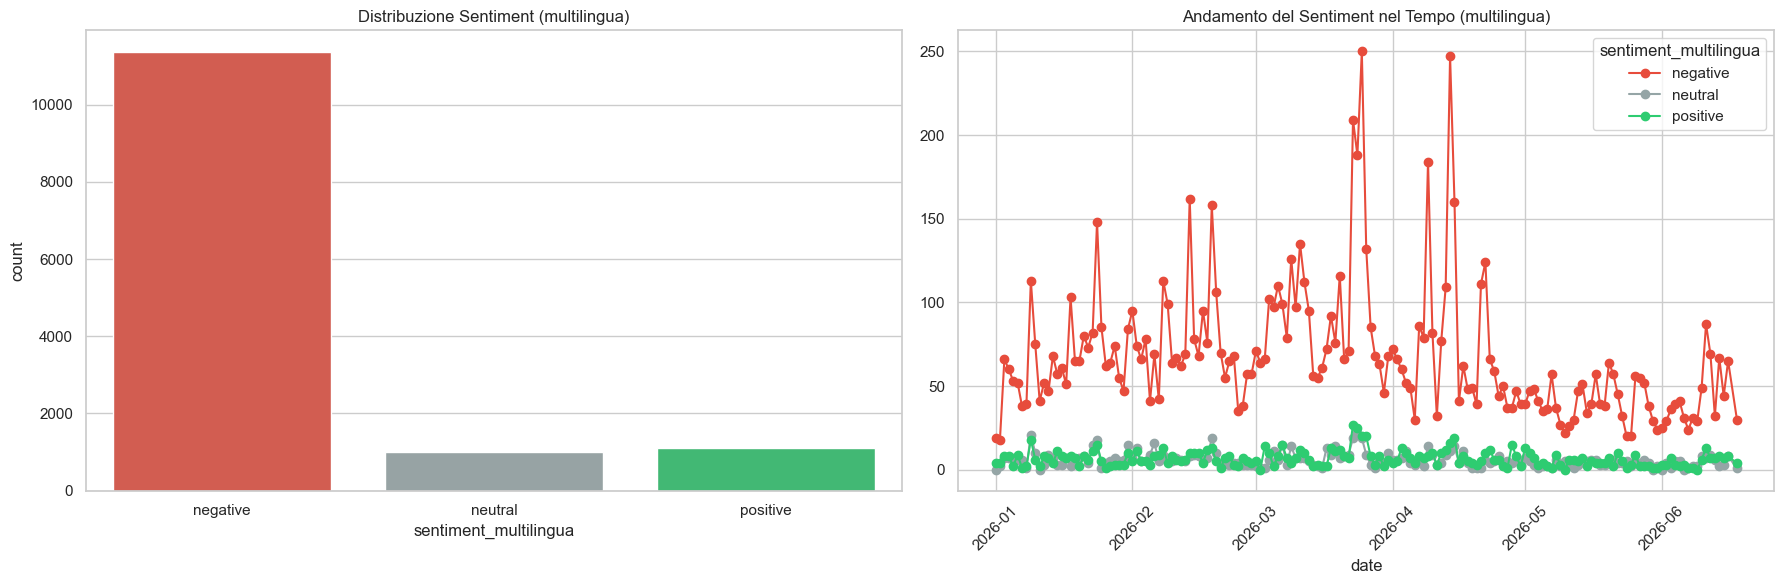

DataFrame salvato in output/cardiffnlp_multilingua.csv


In [6]:

if os.path.exists('output/cardiffnlp_multilingua.csv'):
    df = pd.read_csv('output/cardiffnlp_multilingua.csv')
else:
    df = analyzer.analyze_dataset_custom(df, 'cardiffnlp/twitter-xlm-roberta-base-sentiment', custom_name='multilingua')
    print_report(df, 'multilingua')

save_dataframe_to_csv(df, 'output/cardiffnlp_multilingua.csv')

Inizio analisi su 13465 post, uso il modello: MilaNLProc/feel-it-italian-sentiment...
Progresso: 0% completato (32/13465)
Progresso: 0% completato (64/13465)
Progresso: 0% completato (96/13465)
Progresso: 0% completato (128/13465)
Progresso: 1% completato (160/13465)
Progresso: 1% completato (192/13465)
Progresso: 1% completato (224/13465)
Progresso: 1% completato (256/13465)
Progresso: 2% completato (288/13465)
Progresso: 2% completato (320/13465)
Progresso: 2% completato (352/13465)
Progresso: 2% completato (384/13465)
Progresso: 3% completato (416/13465)
Progresso: 3% completato (448/13465)
Progresso: 3% completato (480/13465)
Progresso: 3% completato (512/13465)
Progresso: 4% completato (544/13465)
Progresso: 4% completato (576/13465)
Progresso: 4% completato (608/13465)
Progresso: 4% completato (640/13465)
Progresso: 4% completato (672/13465)
Progresso: 5% completato (704/13465)
Progresso: 5% completato (736/13465)
Progresso: 5% completato (768/13465)
Progresso: 5% completato (800

C:\Users\vitog\AppData\Local\Temp\ipykernel_1676\2831483860.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


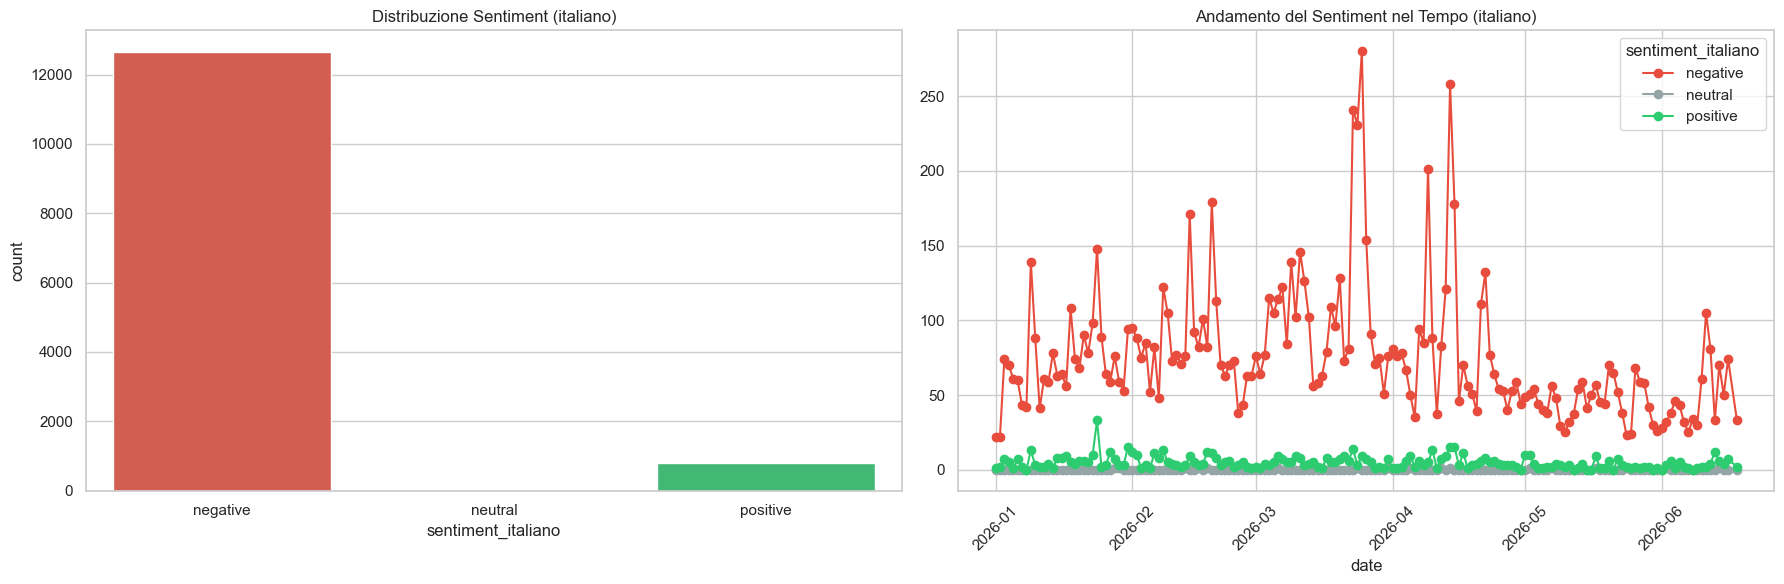

DataFrame salvato in output/MilaNLProc_italiano.csv


In [7]:
if os.path.exists('output/MilaNLProc_italiano.csv'):
    df = pd.read_csv('output/MilaNLProc_italiano.csv')
else:
    df = analyzer.analyze_dataset_custom(df, 'MilaNLProc/feel-it-italian-sentiment', custom_name='italiano')
    print_report(df, 'italiano')

save_dataframe_to_csv(df, 'output/MilaNLProc_italiano.csv')

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Inizio analisi su 13465 post, uso il modello: cardiffnlp/twitter-roberta-base-sentiment-latest...
Progresso: 0% completato (32/13465)
Progresso: 0% completato (64/13465)
Progresso: 0% completato (96/13465)
Progresso: 0% completato (128/13465)
Progresso: 1% completato (160/13465)
Progresso: 1% completato (192/13465)
Progresso: 1% completato (224/13465)
Progresso: 1% completato (256/13465)
Progresso: 2% completato (288/13465)
Progresso: 2% completato (320/13465)
Progresso: 2% completato (352/13465)
Progresso: 2% completato (384/13465)
Progresso: 3% completato (416/13465)
Progresso: 3% completato (448/13465)
Progresso: 3% completato (480/13465)
Progresso: 3% completato (512/13465)
Progresso: 4% completato (544/13465)
Progresso: 4% completato (576/13465)
Progresso: 4% completato (608/13465)
Progresso: 4% completato (640/13465)
Progresso: 4% completato (672/13465)
Progresso: 5% completato (704/13465)
Progresso: 5% completato (736/13465)
Progresso: 5% completato (768/13465)
Progresso: 5% com

C:\Users\vitog\AppData\Local\Temp\ipykernel_1676\2831483860.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


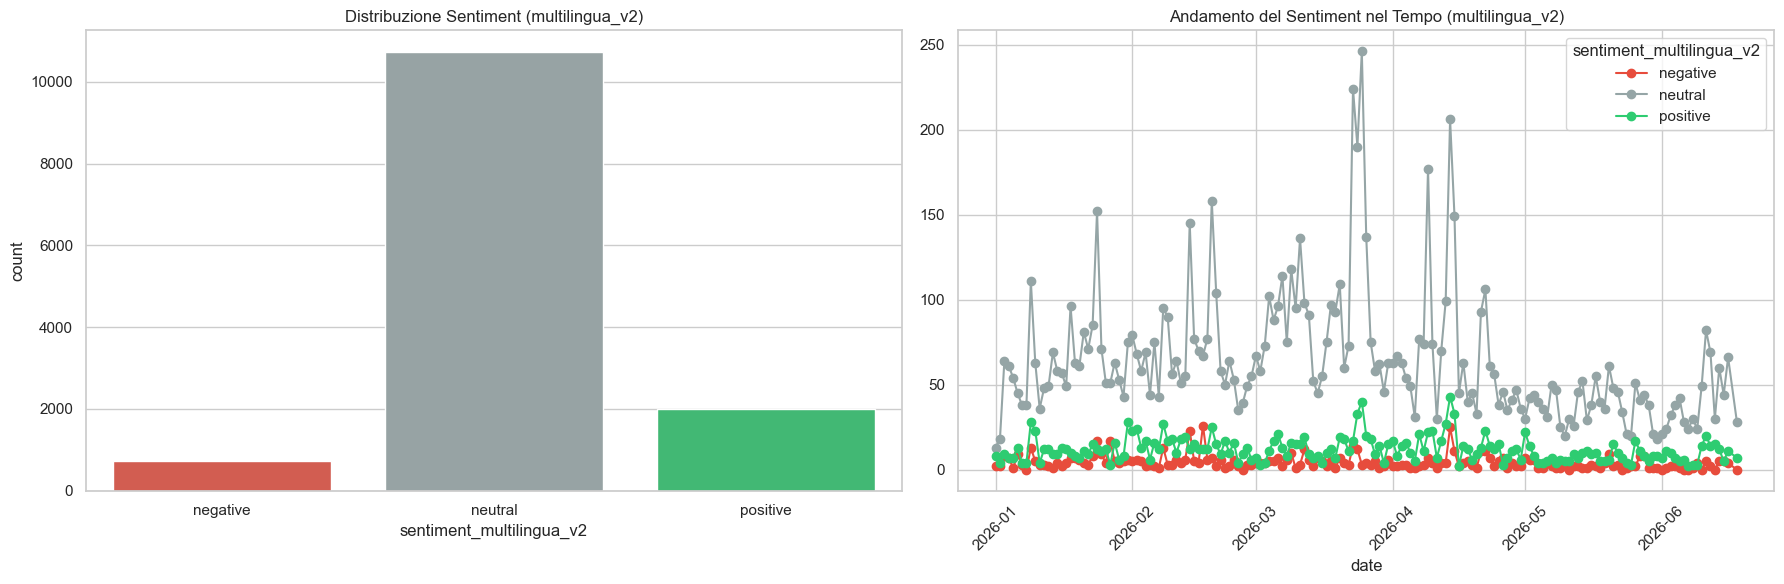

DataFrame salvato in output/cardiffnlp_multilingua_v2.csv


In [8]:
if os.path.exists('output/cardiffnlp_multilingua_v2.csv'):
    df = pd.read_csv('output/cardiffnlp_multilingua_v2.csv')
else:
    df = analyzer.analyze_dataset_custom(df, 'cardiffnlp/twitter-roberta-base-sentiment-latest', custom_name='multilingua_v2')
    print_report(df, 'multilingua_v2')

save_dataframe_to_csv(df, 'output/cardiffnlp_multilingua_v2.csv')

In [18]:
# i risultati sono decisamente diversi tra i modelli
df_daily = df.groupby(['date', 'sentiment_multilingua_v2']).size().unstack(fill_value=0)
print(df_daily.head())

def find_spike_dates(series, threshold_sigma=1.5):
    mean = series.mean()
    std = series.std()
    cutoff = mean + (threshold_sigma * std)
    return series[series > cutoff].index.tolist()

spike_dates_negative = find_spike_dates(df_daily['negative'], threshold_sigma=1.5)
spike_dates_positive = find_spike_dates(df_daily['positive'], threshold_sigma=1.5)
spike_dates_neutral = find_spike_dates(df_daily['neutral'], threshold_sigma=1.5)

df.columns.to_list()

sentiment_multilingua_v2  negative  neutral  positive
date                                                 
2026-01-01                       2       13         8
2026-01-02                       2       18         4
2026-01-03                       8       64         9
2026-01-04                       7       61         7
2026-01-05                       1       54         7


['id',
 'cid',
 'created_at',
 'indexed_at',
 'text_raw',
 'text_clean',
 'hashtags',
 'keyword_source',
 'author_did',
 'author_handle',
 'author_display_name',
 'author_createdAt',
 'like_count',
 'repost_count',
 'reply_count',
 'quote_count',
 'bookmark_count',
 'viewer_like',
 'viewer_repost',
 'viewer_pinned',
 'viewer_bookmarked',
 'date',
 'sent_multilingua_score',
 'sentiment_multilingua',
 'sent_italiano_score',
 'sentiment_italiano',
 'sent_multilingua_v2_score',
 'sentiment_multilingua_v2']

In [41]:
from bertopic import BERTopic

def extract_topics(df, spike_dates, sentiment, model_name='multilingua_v2', model=None):
    df_spike = df[df['date'].isin(spike_dates)]
    testi_spike = df_spike[df_spike[f'sentiment_{model_name}'] == sentiment]['text_clean'].tolist()
    topic_model = model if model is not None else BERTopic(language="italian")
    predictions  = topic_model.fit_transform(testi_spike)
    print(topic_model.get_topic_info())
    return predictions

extract_topics(df, spike_dates_negative, 'negative')

   Topic  Count                                 Name  \
0      0    177                   0_meloni_il_di_non   
1      1     28  1_fascista_milano_ice_milanocortina   

                                      Representation  \
0  [meloni, il, di, non, the, la, trump, and, che...   
1  [fascista, milano, ice, milanocortina, assassi...   

                                 Representative_Docs  
0  [the lying fascist melonis subservience to tru...  
1  [milanocortina il corrotto bugiardo fascista g...  


([0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,


In [42]:
# provo a togliere le stopwords italiane

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import nltk

# downoad delle stopsword
nltk.download('stopwords')
from nltk.corpus import stopwords
italian_stopwords = stopwords.words('italian')

vectorizer_model = CountVectorizer(stop_words=italian_stopwords)
topic_model = BERTopic(vectorizer_model=vectorizer_model)
extract_topics(df, spike_dates_negative, 'negative', model=topic_model)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vitog\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   Topic  Count                                 Name  \
0     -1      9        -1_sinner_amano_melbourne_war   
1      0    123            0_meloni_trump_no_governo   
2      1     30                  1_the_to_meloni_and   
3      2     25  2_milano_fascista_ice_milanocortina   
4      3     18                 3_and_the_is_corrupt   

                                      Representation  \
0  [sinner, amano, melbourne, war, uominiedonne, ...   
1  [meloni, trump, no, governo, dice, perch, refe...   
2  [the, to, meloni, and, but, of, that, she, is,...   
3  [milano, fascista, ice, milanocortina, via, ho...   
4  [and, the, is, corrupt, melonis, nazi, dangero...   

                                 Representative_Docs  
0  [gennaio oltre farwest a hojlund mediaset morb...  
1  [dice ma tu leggi the times dico no dice ma al...  
2  [are you talking about starmer i understand yo...  
3  [milanocortina il corrotto bugiardo fascista g...  
4  [the lying fascist melonis subservience to tru..

([0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  3,
  0,
  0,
  0,
  1,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  3,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
 

In [47]:
# i topic ora sono più puliti ma vanno osservati per ogni spike
def extract_topics_split(df, spike_dates, sentiment, model_name='multilingua_v2', model=None):
    df_temp = df.copy()
    df_temp['date_str'] = df_temp['date'].astype(str)
    
    all_predictions = {}
    
    for date in spike_dates:
        date_str = str(date)
        df_giorno = df_temp[
            (df_temp['date_str'] == date_str) & 
            (df_temp[f'sentiment_{model_name}'] == sentiment)
        ]
        
        testi_giorno = df_giorno['text_clean'].tolist()
        print(f"\n\ndata: {date_str} \t nr post: {len(testi_giorno)}\n\n\n\n")
        
        if len(testi_giorno) == 0:
            continue
                        
        predictions = model.fit_transform(testi_giorno)
        
        print(model.get_topic_info())
        
        all_predictions[date_str] = predictions
        
    return all_predictions


extract_topics_split(df, spike_dates_negative, 'negative', model=topic_model)



data: 2026-01-09 	 nr post: 13




   Topic  Count                                 Name  \
0     -1     13  -1_meloni_accuse_propaganda_notizie   

                                      Representation  \
0  [meloni, accuse, propaganda, notizie, infamant...   

                                 Representative_Docs  
0  [dalla villa allo spionaggio su caputi meloni ...  


data: 2026-01-24 	 nr post: 17




   Topic  Count                             Name  \
0     -1     17  -1_meloni_trump_afghanistan_the   

                                      Representation  \
0  [meloni, trump, afghanistan, the, nato, ice, a...   

                                 Representative_Docs  
0  [meloni stupita inaccettabili le parole di tru...  


data: 2026-01-27 	 nr post: 17




   Topic  Count                              Name  \
0     -1     17  -1_sinner_meloni_melbourne_oltre   

                                      Representation  \
0  [sinner, meloni, melbourne, oltre, gennaio, gh...   

     

{'2026-01-09': ([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
  array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])),
 '2026-01-24': ([-1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1],
  array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])),
 '2026-01-27': ([-1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1],
  array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])),
 '2026-02-08': ([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
  array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])),
 '2026-02-14': ([-1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1,
   -1],
  array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.])),
 '2026-02-17': 

In [52]:
# invece di prendere solo i negative li prendo tutti i tweet di quel giorno, il topic dovrebbe essere generico e non legato al sentiment ?????????

def extract_topics_split_all(df, spike_dates, model_name='multilingua_v2', model=None):
    df_temp = df.copy()
    df_temp['date_str'] = df_temp['date'].astype(str)
    
    all_predictions = {}
    
    for date in spike_dates:
        date_str = str(date)
        df_giorno = df_temp[
            (df_temp['date_str'] == date_str)
        ]
        
        testi_giorno = df_giorno['text_clean'].tolist()
        print(f"\n\ndata: {date_str} \t nr post: {len(testi_giorno)}\n\n\n\n")
        
        if len(testi_giorno) == 0:
            continue
                        
        predictions = model.fit_transform(testi_giorno)
        
        print(model.get_topic_info())
        
        all_predictions[date_str] = predictions
        
    return all_predictions


extract_topics_split_all(df, spike_dates_negative, model=topic_model)



data: 2026-01-09 	 nr post: 152




   Topic  Count                              Name  \
0     -1     32   -1_meloni_to_cransmontana_messa   
1      0    104  0_meloni_stampa_conferenza_trump   
2      1     16       1_video_meloni_italia_fatto   

                                      Representation  \
0  [meloni, to, cransmontana, messa, spionaggio, ...   
1  [meloni, stampa, conferenza, trump, presidente...   
2  [video, meloni, italia, fatto, forza, spiata, ...   

                                 Representative_Docs  
0  [dalla villa allo spionaggio su caputi meloni ...  
1  [abbiamo verificato dichiarazioni fatte da gio...  
2  [guardo video e immagini di questo tipo da ann...  


data: 2026-01-24 	 nr post: 181




   Topic  Count                               Name  \
0      0    167       0_meloni_trump_nobel_giorgia   
1      1     14  1_sinner_comotorino_simona_puente   

                                      Representation  \
0  [meloni, trump, nobel, giorgia, pace, pi, go

{'2026-01-09': ([0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   -1,
   0,
   -1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   0,
   -1,
   -1,
   1,
   -1,
   -1,
   0,
   1,
   1,
   1,
   -1,
   0,
   1,
   0,
   -1,
   0,
   0,
   -1,
   -1,
   -1,
   0,
   -1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   -1,
   0,
   0,
   1,
   -1,
   0,
   0,
   0,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   0,
   1,
   -1,
   1,
   1,
   1,
   1,
   0,
   1,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   -1,
   0,
   -1,
   0,
   -1,
   -1,
   1,
   -1,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   -1,
   -1,
   -1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   0,
   -1,
   0,
   0,
   0,
   -1],
  array([1.        , 1.        , 0.917082

In [58]:
def analyze_all(df, spikes_dict, model=None):
    df_temp = df.copy()
    df_temp['date_str'] = df_temp['date'].astype(str)
    
    struttura_output = {}
    
    for sentiment_label, spike_dates in spikes_dict.items():
        
        for date in spike_dates:
            date_str = str(date)
            
            df_giorno = df_temp[df_temp['date_str'] == date_str]
            testi_giorno = df_giorno['text_clean'].tolist()        
            nr_post = len(testi_giorno)
            
            if nr_post == 0:
                continue
                            
            model.fit_transform(testi_giorno)
            topic_info = model.get_topic_info()
            
            if date_str not in struttura_output:
                struttura_output[date_str] = []
                
            dati_sentiment = {
                "nr_post": nr_post,
                "sentiment": sentiment_label
            }
            
            for _, row in topic_info.iterrows():
                topic_id = row['Topic']
                cluster_key = f"cluster_{topic_id}" if topic_id != -1 else "outliers"
                
                parole_chiave = [word for word, _ in model.get_topic(topic_id)]
                
                dati_sentiment[cluster_key] = parole_chiave
            
            struttura_output[date_str].append(dati_sentiment)
                
    return struttura_output

spikes = {
    'negative': spike_dates_negative,
    'positive': spike_dates_positive,
    'neutral': spike_dates_neutral
}

res = analyze_all(df, spikes, model=topic_model)

In [59]:
res

{'2026-01-09': [{'nr_post': 152,
   'sentiment': 'negative',
   'outliers': ['meloni',
    'trentini',
    'governo',
    'caputi',
    'villa',
    'to',
    'domani',
    'cransmontana',
    'altri',
    'messa'],
   'cluster_0': ['meloni',
    'disciamo',
    'governo',
    'sicurezza',
    'cosa',
    'pi',
    'presidente',
    'giornalisti',
    'perch',
    'mai'],
   'cluster_1': ['conferenza',
    'stampa',
    'meloni',
    'giorgia',
    'anno',
    'presidente',
    'aumento',
    'data',
    'povert',
    'fondi'],
   'cluster_2': ['video',
    'meloni',
    'italia',
    'fatto',
    'forza',
    'spiata',
    'possibile',
    'tre',
    'miracoli',
    'elettorale'],
   'cluster_3': ['trump',
    'venezuela',
    'meloni',
    'groenlandia',
    'daccordo',
    'fa',
    'dice',
    'militare',
    'propagandalive',
    'berlusconi']},
  {'nr_post': 152,
   'sentiment': 'positive',
   'outliers': ['to',
    'for',
    'with',
    'lee',
    'korea',
    'president',
    

In [71]:
negative_tokens_unique = set(([
    parola
    for date, entries in res.items()
    for entry in entries
    if entry.get('sentiment') == 'negative'
    for parola in entry.get('cluster_0', [])
]))

positive_tokens_unique = set(([
    parola
    for date, entries in res.items()
    for entry in entries
    if entry.get('sentiment') == 'positive'
    for parola in entry.get('cluster_0', [])
]))

neutral_tokens_unique = set(([
    parola
    for date, entries in res.items()
    for entry in entries
    if entry.get('sentiment') == 'neutral'
    for parola in entry.get('cluster_0', [])
]))

print(len(negative_tokens_unique))
print(len(negative_tokens_unique-positive_tokens_unique-neutral_tokens_unique))
print((negative_tokens_unique-positive_tokens_unique-neutral_tokens_unique))

61
20
{'tv', 'vince', 'mila', 'iran', 'avvocati', 'insulti', 'prima', 'pd', 'mattei', 'piano', 'of', 'solovyov', 'fascista', 'peace', 'schlein', 'giornalisti', 'putin', 'russo', 'conduttore', 'insulta'}
